# IHLT Final Project

SemEval (Semantic Evaluation Exercises) are a series of workshops which have the main aim of the evaluation and comparison of semantic analysis systems. The data and corpora provided by them have become a ’de facto’ set of bench- marks for the NLP comunity. The SemEval event provides data and evaluation frameworks for several tasks. One of them is Semantic Textual Similarity (STS), the purpose of this project.

All information of 2012’s edition is available at:
- https://www.cs.york.ac.uk/semeval-2012/

All information of 6th task (Sematic Textual Similarity) is available at:
- https://www.cs.york.ac.uk/semeval-2012/task6/index.html

## Authors
- Josep de Cid Rodríguez (<a href="">josep.de.cid@est.fib.upc.edu</a>)
- Gonzalo Recio Domènech (<a href="">gonzalo.recio@est.fib.upc.edu</a>)


If running this notebook in colab, run the following cell to upload data.zip which compresses the training, test and trial dataset.

In [0]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

!unzip data.zip
!rm data.zip

Saving data.zip to data.zip
User uploaded file "data.zip" with length 249113 bytes
Archive:  data.zip
   creating: trial/
  inflating: trial/STS.input.txt     
  inflating: trial/STS.ouput.txt     
  inflating: trial/STS.gs.txt        
  inflating: trial/00-readme.txt     
   creating: test-gold/
  inflating: test-gold/STS.gs.ALL.txt  
  inflating: test-gold/STS.gs.surprise.SMTnews.txt  
  inflating: test-gold/STS.gs.SMTeuroparl.txt  
  inflating: test-gold/STS.gs.MSRvid.txt  
  inflating: test-gold/STS.input.MSRvid.txt  
  inflating: test-gold/STS.gs.surprise.OnWN.txt  
  inflating: test-gold/STS.input.surprise.SMTnews.txt  
  inflating: test-gold/STS.input.SMTeuroparl.txt  
  inflating: test-gold/00-readme.txt  
  inflating: test-gold/STS.input.MSRpar.txt  
  inflating: test-gold/STS.input.surprise.OnWN.txt  
  inflating: test-gold/STS.gs.MSRpar.txt  
   creating: train/
  inflating: train/STS.gs.SMTeuroparl.txt  
  inflating: train/STS.gs.MSRvid.txt  
  inflating: train/STS.input.MS

## Load Data

In [0]:
import os
from tqdm import tqdm_notebook as tqdm

def read_dataset(folder, file_name):
    sentences, scores = [], []

    path = os.path.join(folder, f'STS.input.{file_name}.txt')    
    with open(path, mode='r') as f:
        for line in tqdm(f.readlines(), desc=f'Reading {file_name}', ncols=800):
            a, b = line.strip().split('\t')
            sentences.append((a, b))

    path = os.path.join(folder, f'STS.gs.{file_name}.txt')
    with open(path, 'r') as f:
        for line in tqdm(f.readlines(), desc=f'Reading {file_name} GS', ncols=800):
            scores.append(float(line.strip()))
            
    return sentences, scores

print('READING TRAINING DATA\n')

train_sentences, train_scores = [], []
for path in ['MSRpar', 'MSRvid', 'SMTeuroparl']:
    tmp_sentences, tmp_scores = read_dataset('train', path)
    train_sentences += tmp_sentences
    train_scores += tmp_scores

print('READING TEST DATA\n')

test_sentences, test_scores = [], []
for path in ['MSRpar', 'MSRvid', 'SMTeuroparl', 'surprise.OnWN', 'surprise.SMTnews']:
    tmp_sentences, tmp_scores = read_dataset('test-gold', path)
    test_sentences += tmp_sentences
    test_scores += tmp_scores

READING TRAINING DATA




READING TEST DATA



# Classical NLP Approach

* Tokenization and Stop-Word filtering
* Part Of Speech tagger
* Lemmatizer
* String similarity
* Syntactical similarity (synsets)
* Named Entities


In [0]:
import nltk

nltk.download('stopwords')

nltk.download('punkt')

nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('wordnet_ic')

nltk.download('words')
nltk.download('maxent_ne_chunker')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Unzipping corpora/wordnet.zip.
[nltk_data] Downloading package wordnet_ic to /root/nltk_data...
[nltk_data]   Unzipping corpora/wordnet_ic.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.


True

Helper functions

In [0]:
from nltk.metrics import jaccard_distance
from scipy.stats import pearsonr

def jaccard_distance_sentences(pair):
    return jaccard_distance(set(pair[0]), set(pair[1]))

def pearson_correlation(refs, calculated):
    return pearsonr(refs, calculated)[0]

def calculate_correlation(data, scores):
    distances = list(map(jaccard_distance_sentences, data))
    similarity = list(map(lambda x: 1 - x, distances))
    return pearson_correlation(scores, similarity)

### Tokenization and Stop-Word filtering

In [0]:
from nltk import word_tokenize

def tokenize_pair_sentences(pair, lang='english'):
    return (word_tokenize(pair[0], language=lang)), (word_tokenize(pair[1], language=lang))

tokenized_corpus = list(map(tokenize_pair_sentences, train_sentences))
tokenized_corpus_test = list(map(tokenize_pair_sentences, test_sentences))

In [0]:
import re

from nltk.corpus import stopwords

sw = stopwords.words('english')

def filter_corpus(data):
    filtered_corpus = []
    for pair in data:
        filtered_pair = []
        for sentence in pair:
            # TODO: w.lower()
            filtered_pair.append([w for w in sentence
                                if w.lower() not in sw                   # Remove stopwords
                                and re.search(r'^\w+$', w) is not None]) # Remove punctuation and strange symbols
        filtered_corpus.append(filtered_pair)
    
    return filtered_corpus

filtered_corpus = filter_corpus(tokenized_corpus)
filtered_corpus_test = filter_corpus(tokenized_corpus_test)

### POS Tagging


In [0]:
from nltk import pos_tag

def tag_pair_sentences(model, pair):
    return pos_tag(pair[0]), pos_tag(pair[1])

tagged_corpus = list(map(lambda pair: tag_pair_sentences(pos_tag, pair), filtered_corpus))
tagged_corpus_test = list(map(lambda pair: tag_pair_sentences(pos_tag, pair), filtered_corpus_test))

### Lemmatizing

In [0]:
from nltk.stem import WordNetLemmatizer

pos_translation = {
    'NN': 'n',
    'NNP': 'n',
    'NNS': 'n',
    'NNPS': 'n',
    'VB': 'v',
    'VBD': 'v',
    'VBG': 'v',
    'VBN': 'v',
    'VBP': 'v',
    'VBZ': 'v',
    'JJ': 'a',
    'JJR': 'a',
    'JJS': 'a',
    'RB': 'r',
    'RBR': 'r',
    'RBS': 'r'   
}

wnl = WordNetLemmatizer()

def lemmatize_token(token):
    pos = token[1]
    if pos in pos_translation:
        return [wnl.lemmatize(token[0], pos=pos_translation[pos]), pos]
    return [token[0], pos]

def lemmatize_sentence(sentence):
    return list(map(lemmatize_token, sentence))

def lemmatize_pair_sentences(pair):
    return [
        lemmatize_sentence(pair[0]),
        lemmatize_sentence(pair[1])
    ]

lemmatized_corpus = list(map(lemmatize_pair_sentences, tagged_corpus))
lemmatized_corpus_test = list(map(lemmatize_pair_sentences, tagged_corpus_test))

### Synsets

If two words have high similarity score un WordNet (synset similarity) we use the same word to represent both. Wu-Palmer appeared to be the metric that performed the best.

In [0]:
from copy import deepcopy

from nltk.corpus import wordnet as wn
from nltk.corpus import wordnet_ic as wn_ic
from nltk.corpus.reader.wordnet import WordNetError

brown_ic = wn_ic.ic('ic-brown.dat')

def synsetize_corpus(corpus):
    synsetized_corpus = deepcopy(corpus)

    SIM_METHOD = 'WUP'
    THRESHOLD = 0.9

    for p_idx, pair in enumerate(synsetized_corpus):
        for w1, pos1 in pair[0]:
            if pos1 in pos_translation:
                for w_idx, (w2, pos2) in enumerate(pair[1]):
                    if pos2 in pos_translation and pos1 == pos2 and w1 != w2:
                        try:
                            wn1 = wn.synset(f'{w1}.{pos_translation[pos1]}.01')
                            wn2 = wn.synset(f'{w2}.{pos_translation[pos2]}.01')
                            
                            if SIM_METHOD == 'WUP':
                                sim = wn1.wup_similarity(wn2)
                            elif SIM_METHOD == 'LCH':
                                sim = wn1.lch_similarity(wn2)
                            elif SIM_METHOD == 'LIN':
                                sim = wn1.lin_similarity(wn2, brown_ic)
                            else: # Path
                                sim = wn1.path_similarity(wn2)

                            if (sim is not None and sim > THRESHOLD):
                                synsetized_corpus[p_idx][1][w_idx][0] = w1

                        except WordNetError:
                            # Some words are not in WordNet
                            continue
            
    return synsetized_corpus

synsetized_corpus = synsetize_corpus(lemmatized_corpus)
synsetized_corpus_test = synsetize_corpus(lemmatized_corpus_test)

### Named Entities
Detect NE and tag them as a special PoS label.

In [0]:
from nltk import ne_chunk

def get_words_and_NEs(sentence):
    tree = ne_chunk(sentence, binary=True)
    
    result = []
    for chunk in tree:
        if hasattr(chunk, 'label'):
            result.append((' '.join(c[0] for c in chunk), 'NE'))
        else:
            result.append(chunk)
    return result, tree

def ne_simplify(data):
    ne_simplified_corpus = []
    
    for (s1, s2) in data:
        result1, _ = get_words_and_NEs(s1)
        result2, _ = get_words_and_NEs(s2)
        ne_simplified_corpus.append([result1, result2])
    
    return ne_simplified_corpus

ne_simplified_corpus = ne_simplify(synsetized_corpus)
ne_simplified_corpus_test = ne_simplify(synsetized_corpus_test)

In [0]:
def remove_pos(pair):
    sentence_1 = []
    for sentence in pair[0]:
        sentence_1.append(sentence[0].lower())

    sentence_2 = []
    for sentence in pair[1]:
        sentence_2.append(sentence[0].lower())

    return sentence_1, sentence_2

def remove_word(pair):
    sentence_1 = []
    for (_, pos) in pair[0]:
        sentence_1.append(pos)

    sentence_2 = []
    for (_, pos) in pair[1]:
        sentence_2.append(pos)

    return sentence_1, sentence_2

print('These are the correlations obtained with each step (each one is applied over the previous)')
print('- Tokenization:', calculate_correlation(tokenized_corpus, train_scores))
print('- Stopwords:', calculate_correlation(filtered_corpus, train_scores))
print('- Lemmatization:', calculate_correlation(list(map(remove_pos, lemmatized_corpus)), train_scores))
print('- Synsets reduction:', calculate_correlation(list(map(remove_pos, synsetized_corpus)), train_scores))
print('- NE reduction:', calculate_correlation(list(map(remove_pos, ne_simplified_corpus)), train_scores))

These are the correlations obtained with each step (each one is applied over the previous)
- Tokenization: 0.37670210545330995
- Stopwords: 0.5679575608144589
- Lemmatization: 0.6086507168088251
- Synsets reduction: 0.6142713586424081
- NE reduction: 0.5880000940547825


# Moden NLP Approaches: Neural Networks

In this section we are going to take into account the training set provided in order to build a NN model and apply some modern approaches.

##### Word Embeddings - GloVe

For word embeddings we use the pre-trained model GloVe-6B. First of all we need to download it:

In [0]:
import os

if not os.path.exists('/glove'):
    !wget https://nlp.stanford.edu/data/wordvecs/glove.6B.zip

    !mkdir glove
    !unzip glove.6B.zip -d /glove

    !rm glove.6B.zip

--2019-12-12 10:32:35--  https://nlp.stanford.edu/data/wordvecs/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: http://downloads.cs.stanford.edu/nlp/data/wordvecs/glove.6B.zip [following]
--2019-12-12 10:32:35--  http://downloads.cs.stanford.edu/nlp/data/wordvecs/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182753 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glove.6B.zip        100%[===================>] 822.24M  2.13MB/s    in 6m 26s  

2019-12-12 10:39:02 (2.13 MB/s) - ‘glove.6B.zip’ saved [862182753/862182753]

Archive:  glove.6B.zip
  inflating: /glove/glove.6B.100d.txt  
  inflating: /glove/gl

In [0]:
import numpy as np

LATENT_DIM = 300


# Load GloVe embeddings into a dictionary

def load_glove():
    file = f'/glove/glove.6B.{LATENT_DIM}d.txt'
    with open(file, mode='r') as f:
        model = {}
        for line in tqdm(f.readlines(), desc='Loading GloVe...', ncols=800):
            splitLine = line.split()
            word = splitLine[0]

            embedding = np.array([float(val) if val != '.' else 0.0 for val in splitLine[1:]])
            model[word] = embedding
        print(f'Done, {len(model)} words loaded!')
        return model


# Apply word embedding to each word of our sentences in the corpus

def embed_sentences(model, data):
    embedded_sentences = deepcopy(data)
    for p_idx, pair in enumerate(embedded_sentences):
        for s_idx, sentence in enumerate(pair):
            for w_idx, (w, p) in enumerate(sentence):
                if w in model:
                    embedded_word = model[w]
                else:
                    embedded_word = np.random.normal(scale=0.6, size=(LATENT_DIM,))
                embedded_sentences[p_idx][s_idx][w_idx].append(embedded_word)

    return embedded_sentences


# Create Weights Matrix with indexed words-indices

def create_weights_matrix(model, data):
    vocab = []
    for pair in data:
        for sentence in pair:
            for word, _ in sentence:
                vocab.append(word)
    
    vocab = ['[UNK]', '[PAD]'] + list(set(vocab))
    word2idx = {word: idx for idx, word in enumerate(vocab)}

    matrix_len = len(vocab)
    weights_matrix = np.zeros((matrix_len, LATENT_DIM))

    for i, word in enumerate(vocab):
        if word in model:
            weights_matrix[i] = model[word]
        else:
            weights_matrix[i] = np.random.normal(scale=0.6, size=(LATENT_DIM,))

    return weights_matrix, word2idx


# Apply word to index mapping to each word of our sentences in the corpus
# We need to align the sentences so we add a special token [PAD] to fit max sentence length

def map_words_to_idx(data):
    words_idx = []
    
    max_len_sentence = 0
    for pair in data:
        for sentence in pair:
            if len(sentence) > max_len_sentence:
                max_len_sentence = len(sentence)

    for s0, s1 in data:
        s0_idx = [word2idx.get(tok[0], word2idx['[UNK]']) for tok in s0]
        s0_idx += [word2idx['[PAD]']] * (max_len_sentence - len(s0_idx))

        s1_idx = [word2idx.get(tok[0], word2idx['[UNK]']) for tok in s1]
        s1_idx += [word2idx['[PAD]']] * (max_len_sentence - len(s1_idx))

        words_idx.append([s0_idx, s1_idx])
    return words_idx

In [0]:
glove_model = load_glove()

embedded_sentences = embed_sentences(glove_model, lemmatized_corpus)
embedded_sentences_test = embed_sentences(glove_model, lemmatized_corpus_test)

weights_matrix, word2idx = create_weights_matrix(glove_model, lemmatized_corpus)


Done, 400001 words loaded!


#### Data Augmentation

Our dataset is not large enough to apply Deep Learning techniques properly as it only have around 2K instances, and we would need much more to train a robust regressor.

For that reason, we try to apply data augmentation techniques to generate more paraphase instances from the training dataset by swapping the sentence pairs. Doing this, from the network's point of view, these are totally new samples as the order of the features that it receives as the input is changed. We noticed that by doing this it helped significantly to obtain better results.

We also tried to make our regressor more robust, by masking some tokens with a random probability, in order to train to avoid overfitting. This produced better results in some cases, but much worse in others, which leads us to think that it adds some unstability to our model. Hence we finally decided to don't apply this step, by setting the masking probability to 0.

In [0]:
def mask_sentences(sentences, mask='[MASK]', p=0.5):
    sentences = deepcopy(sentences)
    for p_idx, pair in enumerate(embedded_sentences):
        for s_idx, sentence in enumerate(pair):
            if np.random.rand() < p:
                r_idx = np.random.randint(0, len(sentence))
                embedded_sentences[p_idx][s_idx][r_idx][0] = mask
    return sentences

In [0]:
# Add reversed order pairs to x2 the training data size
train_data_aug = embedded_sentences
train_data_aug += [[s1, s0] for s0, s1 in train_data_aug]
train_target_aug = train_scores + train_scores

# Mask within a certain probability random tokens
train_data_aug = mask_sentences(train_data_aug, mask='[UNK]', p=0)

# Reassign testing data
test_data = embedded_sentences_test
test_target = test_scores

#### Extracting Features

##### Feature Extraction

For training the NN model, we extract **individual features** for each sentence and **common features** (similarities and distances) considering both sentences. 

Individual features:
 - Length
 - \# of capital letters
 - \# of occurences of some PoS tags (number of Nouns, Verbs, Adjectives, Adverbs, Cardinals, ...)
 - \# of Named Entities

Common featues:
 - Word intersection
 - disntance and similarity metrics between sets (Jaccard, Ovelaping, Sorensen-Dice)
 - Synset intersection
 - Synset similarity metrics (Path,  Wu-Palmer Leacock-Chodorow, Lin)
 - cosine similarity (between TF-IDF vector representation of the sentences)
 - edit distance
 - Named Entities intersection
 - n-grams intersention (n=2,3,4)
 - character n-grams intersection (n=2,3,4)
 

In [0]:
from functools import reduce

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from nltk import ngrams, edit_distance

def get_ne_sentence(sentence):
    p1 = [p[0] for p in lemmatized_corpus]
    if sentence in p1:
        return ne_simplified_corpus[p1.index(sentence)][0]
    p2 = [p[1] for p in lemmatized_corpus]
    if sentence in p2:
        return ne_simplified_corpus[p2.index(sentence)][1]
    p1 = [p[0] for p in lemmatized_corpus_test]
    if sentence in p1:
        return ne_simplified_corpus_test[p1.index(sentence)][0]
    p2 = [p[1] for p in lemmatized_corpus_test]
    if sentence in p2:
        return ne_simplified_corpus_test[p2.index(sentence)][1]
    return []

def extract_sentence_features(sentence):
    def count_pos(s, pos, full=False):
        return len(list(filter(lambda token:
                               token[1] == pos if full else token[1][0] == pos, s)))

    features = {
        'length': len(sentence),
        '#capitalized': reduce(lambda acc, p: acc + (p[0][0].upper() == p[0][0]), sentence, 0),

        '#verbs': count_pos(sentence, 'V'),
        '#nouns': count_pos(sentence, 'N'),
        '#adjs': count_pos(sentence, 'J'),
        '#advs': count_pos(sentence, 'R'),
        '#nums': count_pos(sentence, 'CD', full=True),
        '#mods': count_pos(sentence, 'MD', full=True),
        '#ints': count_pos(sentence, 'IN', full=True),
        #'#NE': count_pos(get_ne_sentence(sentence), 'NE', full=True),
    }

    if not len(sentence):
        mean_embedded_sentence = list(np.random.rand((LATENT_DIM)))
    else:
        mean_embedded_sentence = list(np.mean(list(map(lambda x: x[2], sentence)), axis=0))

    return list(features.values())# + mean_embedded_sentence

def extract_pair_features(pair):
    s0, s1 = remove_pos(pair)

    syn0 = []
    syn1 = []

    path_sim = []
    wup_sim = []
    lch_sim = []
    lin_sim = []

    for w0, pos0, _ in pair[0]:
        if pos0 in pos_translation:
            for w1, pos1, _ in pair[1]:
                if pos1 in pos_translation and pos0 == pos1 and w0 != w1:
                    try:
                        # Synsets
                        wn0 = wn.synset(f'{w0}.{pos_translation[pos0]}.01')
                        syn0.append(wn0)

                        wn1 = wn.synset(f'{w1}.{pos_translation[pos1]}.01')
                        syn1.append(wn1)

                        # Similarities
                        sim = wn0.path_similarity(wn1)
                        if sim is not None:
                            path_sim.append(sim)
                        
                        sim = wn0.wup_similarity(wn1)
                        if sim is not None:
                            wup_sim.append(sim)

                        sim = wn0.lch_similarity(wn1)
                        if sim is not None:
                            lch_sim.append(sim)

                        sim = wn0.lin_similarity(wn1, brown_ic)
                        if sim is not None:
                            lin_sim.append(sim)

                    except WordNetError:
                        continue
    
    path_sim = np.mean(path_sim) if path_sim else 0
    wup_sim = np.mean(wup_sim) if wup_sim else 0
    lch_sim = np.mean(lch_sim) if lch_sim else 0
    lin_sim = np.mean(lin_sim) if lin_sim else 0

    if len(s0) and len(s1):
        tf_idf0 = vectorizer.transform(s0)
        tf_idf1 = vectorizer.transform(s1)
        tf_idf_cos_sim = cosine_similarity(tf_idf0, tf_idf1)[0][0]
    else:
        tf_idf_cos_sim = 0

    def jaccard_dist_ngrams(s1, s2, n_values, char=False):
        if char:
            s1 = ' '.join(s1)
            s2 = ' '.join(s2)

        n_grams = []
        for n in n_values:
            s1n, s2n = set(ngrams(s1, n)), set(ngrams(s2, n))
            if not len(s1n) or not(len(s2n)):
                n_grams.append(0)
            else:
                n_grams.append(len(s1n & s2n)) # jaccard_distance(s1n, s2n)
        return n_grams

    def edit_distance_sentences(s1, s2):
        return edit_distance(' '.join(s1), ' '.join(s2))

    def NE_jaccard(s0, s1):
        ne1 = [ne for ne in get_ne_sentence(s0) if ne[1] == 'NE']
        ne2 = [ne for ne in get_ne_sentence(s1) if ne[1] == 'NE']
        return len(set(ne1) & set(ne2))

    features = {
        'intersection': len(set(s0) & set(s1)),
        'jaccard': jaccard_distance(set(s0), set(s1)) if len(s0)*len(s1) else 1,
        'overlap': len(set(s0) & set(s1)) / max(1, min(len(set(s0)), len(set(s1)))),
        'dice': 2 * len(set(s0) & set(s1)) / (len(set(s0)) + len(set(s1))),
        'syn_interesction': len(set(syn0) & set(syn1)),
        'syn_jaccard': jaccard_distance(set(syn0), set(syn1)) if len(set(syn0))*len(set(syn1)) else 1,
        'path_sim': path_sim,
        'wup_sim': wup_sim,
        'lch_sim': lch_sim,
        'lin_sim': lin_sim,
        'tf_idf': tf_idf_cos_sim,
        'edit_dist': edit_distance_sentences(s0, s1),
        #'NE_jaccard': NE_jaccard(pair[0], pair[1])
    }

    return list(features.values())\
        + jaccard_dist_ngrams(s0, s1, n_values=[3], char=True)\
        + jaccard_dist_ngrams(s0, s1, n_values=[3], char=False)
 
def extract_features(sentences):
    features = []
    for pair in sentences:
        s_features = []
        s_features += extract_sentence_features(pair[0])
        s_features += extract_sentence_features(pair[1])
        s_features += extract_pair_features(pair)
        features.append(np.array(s_features))

    return np.array(features)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

corpus_for_tf_idf = []
for pair in lemmatized_corpus:
    p0, p1 = remove_pos(pair)
    corpus_for_tf_idf.append(' '.join(p0))
    corpus_for_tf_idf.append(' '.join(p1))

vectorizer = TfidfVectorizer()
vectorizer = vectorizer.fit(corpus_for_tf_idf)

In [0]:
features_corpus = extract_features(train_data_aug)
features_corpus_test = extract_features(test_data)

words_idx = map_words_to_idx(train_data_aug)
words_idx_test = map_words_to_idx(test_data)

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:111: DeprecationWarning: generator 'ngrams' raised StopIteration


In order to fit properly the Neural Network and avoid gradient problems we first normalize the feature values in range [0, 1].

In [0]:
from sklearn.preprocessing import MinMaxScaler

def normalize_features(features, scaler=None):
    if scaler is None:
        scaler = MinMaxScaler()
        scaler.fit(features)
    return scaler.transform(features), scaler

norm_features_corpus, sc = normalize_features(features_corpus)
norm_features_corpus_test, _ = normalize_features(features_corpus_test, sc)

norm_scores = np.array(train_target_aug) / 5
norm_scores_test = np.array(test_target) / 5

##### Visualizing Features

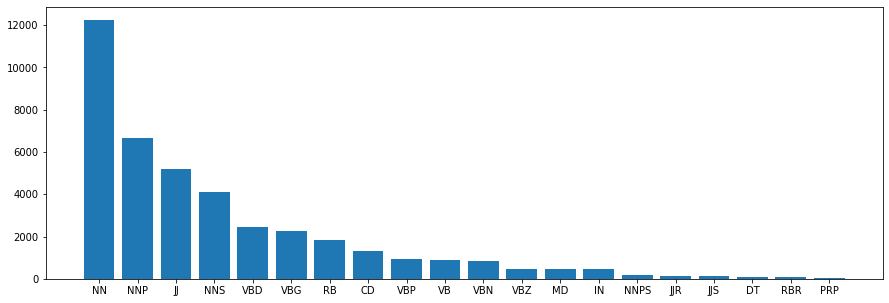

In [0]:
from collections import Counter

import matplotlib.pyplot as plt

pos_counter = Counter()
for pair in lemmatized_corpus:
    s0, s1 = remove_word(pair)
    pos_counter.update(s0)
    pos_counter.update(s1)

%matplotlib inline

most_common_pos = pos_counter.most_common()[:20]
plt.figure(figsize=(15, 5))
plt.bar(list(map(lambda x: x[0], most_common_pos)),
        list(map(lambda x: x[1], most_common_pos)))
plt.show()

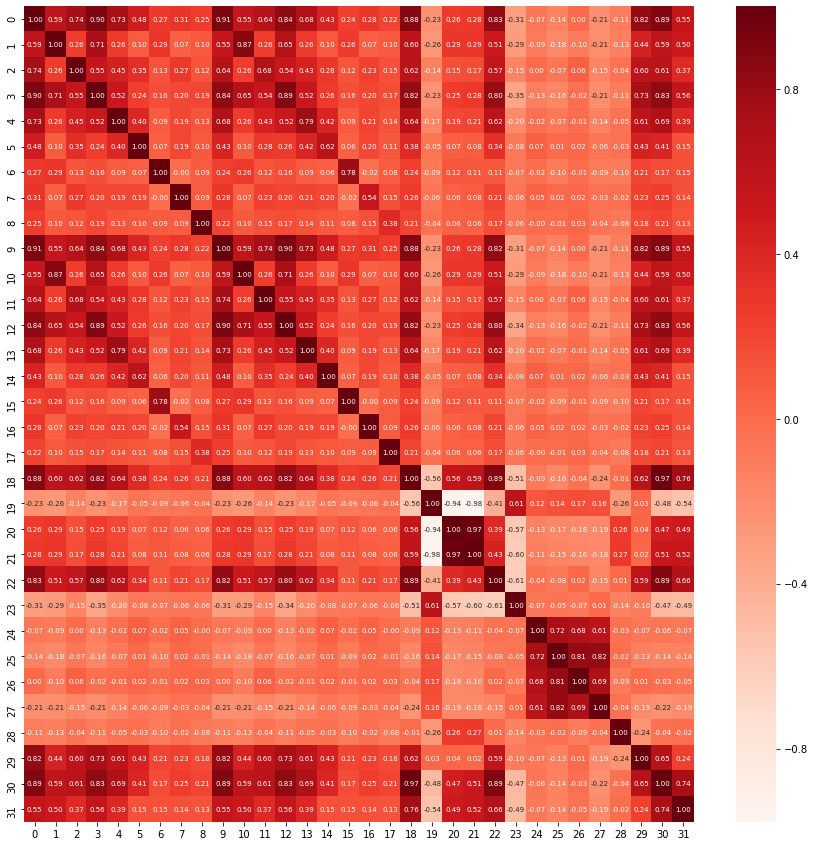

In [0]:
import seaborn as sns
import pandas as pd

plt.figure(figsize=(15, 15))
df = pd.DataFrame(norm_features_corpus)
cor = df.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds, annot_kws={'size': 7}, fmt='.2f')
plt.show()

#### Model
Neural Net implementation in PyTorch.


In [0]:
import torch

EPOCHS = 500
BATCH_SIZE = 256
PATIENCE = 25

cpu = torch.device('cpu')
cuda = torch.device('cuda')
device = cuda if torch.cuda.is_available() else cpu

###### **Torch Dataset**

We turn our data into a torch Dataset to easily access helpers in the training process.

In [0]:
from torch.utils.data import Dataset

class STS(Dataset):
    def __init__(self, X, y, words_idx, transform=None):
        self.X = X
        self.y = y
        self.words_idx = words_idx
        self.transform = transform
        
    def __len__(self):
        return self.X.shape[0]
    
    def __getitem__(self, index):
        features = torch.FloatTensor(self.X[index, :])
        scores = torch.FloatTensor([self.y[index]])
    
        raw0 = torch.LongTensor(self.words_idx[index][0])
        raw1 = torch.LongTensor(self.words_idx[index][1])
        
        return features, scores, raw0, raw1

# Create train dataset
train_dataset = STS(X=norm_features_corpus,
                    y=norm_scores,
                    words_idx=words_idx)

# Create test dataset
test_dataset = STS(X=norm_features_corpus_test,
                   y=norm_scores_test,
                   words_idx=words_idx_test)

###### **Model Implementation**

As additional input data for this network, we will use GloVe word embeddings. We will input the network the word indices of each sentence in the pair calculated previously. To transform this indices to the corresponding embeddings for each one, we need to build an *Embedding Layer*, which loads the weight matrix, and we allow it to freeze or unfreeze the weights to perform or not a fine-tuning process.

In [0]:
def create_emb_layer(weights_matrix, non_trainable=False):
    num_embeddings, embedding_dim = weights_matrix.shape
    emb_layer = nn.Embedding(num_embeddings, embedding_dim)
    emb_layer.load_state_dict({'weight': torch.FloatTensor(weights_matrix)})
    if non_trainable:
        emb_layer.weight.requires_grad = False

    return emb_layer, num_embeddings, embedding_dim

Our model consists in some small networks:
- **Embedding Layer:** We input the pair of sentences (independently) to obtain a embedded input of shape *(max_sentence_size, emb_size)*
- **RNN:** To use the embedding information for sentence level, instead of simply doing the mean, which may not be the best approach, we pass it through a Recurrent Neural Network, GRU in our case (Gated Recurrent Unit) using each embedded word as a different timestep, and we take the last timestep as the hidden sentence representation. Having two representations of size *(latent_size)* (for each sentence of the pair), we merge those by subtracting one to the other, representing the distance between both.
- **FFNN:** This network, takes the original numeric features plus the output of the *RNN*, and acting as a MLP performs a regression for the similarity score.

In [0]:
import torch.nn as nn
from torch.nn import functional as F

class STS_Net(nn.Module):
    def __init__(self, inp_size, weights_matrix, layers, rnn_dim, finetune):
        super(STS_Net, self).__init__()

        self.embedding, _, emb_dim = create_emb_layer(weights_matrix, finetune)

        hidden_dim = rnn_dim
        self.rnn = nn.GRU(LATENT_DIM, hidden_dim, 1,
                          batch_first=True, bidirectional=False)

        last_dim = inp_size + hidden_dim
        self.hid = []
        for hid_dim in layers:
            hid = nn.Linear(last_dim, hid_dim)
            last_dim = hid_dim
            
            self.hid.append(hid)
            self.hid.append(nn.LeakyReLU())
            self.hid.append(nn.Dropout(0.1))
            
        self.hid = nn.Sequential(*self.hid)
        self.out = nn.Linear(last_dim, 1)

    def forward(self, x, raw0, raw1):
        emb_s0 = self.embedding(raw0)
        emb_s0 = F.dropout(emb_s0, 0.1)
        _, emb_s0 = self.rnn(emb_s0)
        emb_s0 = torch.squeeze(emb_s0)

        emb_s1 = self.embedding(raw1)
        emb_s1 = F.dropout(emb_s1, 0.1)
        _, emb_s1 = self.rnn(emb_s1)
        emb_s1 = torch.squeeze(emb_s1)

        emb_pair = emb_s0 - emb_s1

        x = torch.cat([x, emb_pair], dim=1)

        x = self.hid(x)

        x = torch.sigmoid(self.out(x))
        return x.view(-1)

    def __init_hidden(self):
        weight = next(self.parameters()).data
        hidden = weight.new(self.n_layers, batch_size, self.hidden_dim).zero_().to(device)
        return hidden

We also initialize in a custom way the weights of the Neural Network depending on the type of the layer.

In [0]:
def init_weights(m):
    if type(m) == nn.Linear:
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)
    if type(m) == nn.GRU:
        for name, param in m.named_parameters():
            if 'weight_ih' in name:
                torch.nn.init.xavier_uniform_(param.data)
            elif 'weight_hh' in name:
                torch.nn.init.orthogonal_(param.data)
            elif 'bias' in name:
                param.data.fill_(0)

##### Training

In [0]:
from torch.utils.data import DataLoader

def get_epoch_correlation(model, criterion, dataset):
    features = dataset[:][0].to(device)
    scores = dataset[:][1].view(-1)

    raw0 = [dataset[i][2] for i in range(len(dataset))]
    raw0 = torch.stack(raw0, axis=0).to(device)

    raw1 = [dataset[i][3] for i in range(len(dataset))]
    raw1 = torch.stack(raw1, axis=0).to(device)

    logits = model(features, raw0, raw1).to(cpu)
    loss = criterion(logits, scores)

    return scores.mean(), pearson_correlation(scores.detach().numpy(),
                                              logits.detach().numpy())

def train(train_dataset, test_dataset, C):
    n_features = train_dataset[0][0].size()[0]
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = STS_Net(inp_size=n_features,
                    weights_matrix=weights_matrix,
                    layers=C['layers'],
                    rnn_dim=C['rnn_dim'],
                    finetune=C['FTE'] == 0)
    
    model = model.to(device)
    model.apply(init_weights)

    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=C['lr'], weight_decay=C['L2'])
    criterion = nn.MSELoss()

    train_corr, test_corr = [], []

    best_corr = 0
    best_epoch_idx = 0
    worse_epochs = 0

    for epoch_idx in tqdm(range(EPOCHS), desc='Training...', ncols=800):
        model.train()

        if epoch_idx > 0 and epoch_idx == C['FTE']:
            print('Stopping fine-tuning of embeddings')
            model.embedding.weight.requires_grad = False

        for features, scores, raw0, raw1 in train_loader:
            # Send data to CPU/GPU
            features = features.to(device)
            scores = scores.view(-1).to(device)
            raw0 = raw0.to(device)
            raw1 = raw1.to(device)

            # Clear optimizer gradients
            optimizer.zero_grad()
        
            # Calculate loss
            logits = model(features, raw0, raw1)
            loss = criterion(logits, scores)
            
            # Calculate gradients and optimize params
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            # Train data correlation
            _, corr = get_epoch_correlation(model, criterion, train_dataset)
            train_corr.append(corr)

            # Test data correlation
            _, corr = get_epoch_correlation(model, criterion, test_dataset)
            test_corr.append(corr)

            # For Hyperparameter tuning
            if HYPER_OPTIM:
                track.log(correlation=corr)

            # Early Stopping
            if corr > best_corr:
                best_corr = corr
                best_epoch_idx = epoch_idx
                worse_epochs = 0
            else:
                worse_epochs += 1
                if worse_epochs == PATIENCE:
                    print(f'EARLY STOPPING at epoch {epoch_idx} (best epoch: {best_epoch_idx})')
                    print(f'Test correlation: {max(test_corr)}')
                    return model, train_corr[:best_epoch_idx + 1], test_corr[:best_epoch_idx + 1]

    return model, train_corr, test_corr

##### **Evaluation of the model**

Due to the stochasticity of the Neural Networks, we run the experiment several times, keeping the best model obtained. We play with different parameters:
- Fine-Tuning Epochs
- Learning Rate
- L2 weight decay
- Number of layers and units/layer
- Latent dimension for RNN

In [0]:
from torchsummary import summary

HYPER_OPTIM = False

best_model, best_train_corr, best_test_corr = None, [], [0]
print('Running 5 experiments:')
for i in range(3):
    model, train_corr, test_corr = train(train_dataset, test_dataset, {
        'FTE': 0,
        'lr': 0.001,
        'L2': 0,
        'layers': [1000, 500, 200, 50],
        'rnn_dim': 300
    })

    if test_corr[-1] > best_test_corr[-1]:
        best_model = model
        best_train_corr = train_corr
        best_test_corr = test_corr

best_corr_idx = np.argmax(best_test_corr)
print('\nBest execution:')
print(f'\t> Train correlation: {best_train_corr[best_corr_idx]}')
print(f'\t> Test correlation: {best_test_corr[best_corr_idx]}\n')

print(best_model)

Running 5 experiments:


Visualization of the training and test correlation scores along the epochs.

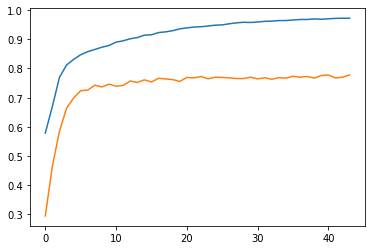

Train correlation: 0.9725522180169875
Test correlation:  0.7778356184221205


In [0]:
import matplotlib.pyplot as plt

%matplotlib inline

epochs = len(best_train_corr)
plt.plot(range(epochs), best_train_corr)
plt.plot(range(epochs), best_test_corr)

plt.show()

print('Train correlation:', max(best_train_corr))
print('Test correlation: ', max(best_test_corr))

#### Hyperparameter Optimization

In [0]:
!pip uninstall -y pyarrow
!pip install ray[tune]

In [0]:
import ray
from ray import tune
from ray.tune.schedulers import ASHAScheduler

search_space = {
    'FTE': int(tune.uniform(0, 10)),
    'lr': tune.sample_from(lambda spec: 10**(-10 * np.random.rand())),
    'L2': tune.uniform(0, 0.25)
    'layers': [np.random.choice([100, 200, 500, 1000]) for _ in np.random.randint(0, 5)],
    'rnn_dim': np.random.choice([100, 200, 300])
}

# Library has some problems running on GPU
device = cpu

ray.shutdown()
ray.init(num_cpus=2, num_gpus=1)

HYPER_OPTIM = True

analysis = tune.run(lambda c: train(train_dataset, test_dataset, c),
                    num_samples=30,
                    scheduler=ASHAScheduler(metric='correlation', mode='max'),
                    config=search_space)

print('Best config: ', analysis.get_best_config(metric='correlation'))

# Deep Learning SotA Approach: Transformers

Independently, we tried the SotA approaches in NLP, using transformers to produce sentence embeddings and use these to obtain the similarity score. We tried several models to compare and obtain the best architecture for this task.

In [0]:
# Install transformers library
!pip install sentence-transformers

     |████████████████████████████████| 51kB 2.0MB/s 
     |████████████████████████████████| 368kB 9.7MB/s 
     |████████████████████████████████| 1.0MB 20.5MB/s 
     |████████████████████████████████| 675kB 48.5MB/s 
     |████████████████████████████████| 860kB 43.5MB/s 
  Created wheel for sentence-transformers: filename=sentence_transformers-0.2.4.1-cp36-none-any.whl size=61094 sha256=aba0ce4db90a8df37ede6cb12fc0d9e6feb896cf3f4e6c3634f84d75c2f66c33
  Stored in directory: /root/.cache/pip/wheels/12/a5/1c/03b7d87e027121fe1e23048007594e73f39a23e833658529c7
  Created wheel for regex: filename=regex-2019.12.9-cp36-cp36m-linux_x86_64.whl size=609160 sha256=33ba2095cec7315cee034e0937a165510800c91f154470e04dcf42d153a16388
  Stored in directory: /root/.cache/pip/wheels/0d/fb/b3/a89169557229468c49ca64f6839418f22461f6ee0a74f342b1
  Created wheel for sacremoses: filename=sacremoses-0.0.35-cp36-none-any.whl size=883999 sha256=9bec714ea4a71166e632755d933123971246da24134eff68032733ef2dfc76e9
 

In [0]:
from sentence_transformers import SentenceTransformer
from scipy.spatial.distance import cosine

device = cuda if torch.cuda.is_available() else cpu

model_names = [
    'bert-base-nli-stsb-mean-tokens',
    'bert-large-nli-stsb-mean-tokens',
    'roberta-base-nli-stsb-mean-tokens',
    'roberta-large-nli-stsb-mean-tokens',
    'distilbert-base-nli-stsb-mean-tokens'
]

for name in model_names:
    model = SentenceTransformer(name)
    model = model.to(cuda)

    representations_a = []
    representations_b = []

    with torch.no_grad():
        for (sent_a, sent_b) in tqdm(test_sentences, desc='Embedding Sentences', ncols=800):
            sentences_embeddings = model.encode([sent_a, sent_b])
            representations_a.append(sentences_embeddings[0])
            representations_b.append(sentences_embeddings[1])

    obtained_scores = []
    for idx, (repr_a, repr_b) in enumerate(zip(representations_a, representations_b)):
        score = 1 - cosine(repr_a, repr_b)
        obtained_scores.append(score)

    corr_score = pearsonr(test_scores[:len(obtained_scores)], obtained_scores)[0]
    print(f'{name}: {corr_score}')

# Conclusions
- With Classical NLP approaches we managed to reach a **0.61427** correlation by mixing lemmatizing and synset similarities, using a simple Jaccard Distance metric. In this approach is very useful to simplify the data by lemmatizing, using POS, remove useless words in terms of information (stop-words...).

- With Modern NLP approaches we achieved a **0.7988** by doing feature engineering, training a Neural Network and fitting it with several features related to lexical, syntactical, semantical properties and, additionally, word embeddings. Feature engineering is such a difficult task as it's difficult to determine which features help the most in the neural network. We tried to remove correlated features, which should help but it produced the opposite effect. Some of the relevant things that improved correlation are:
    - Feature extraction
    - Data augentation
    - GloVe embeddings + RNN

- Using State of the Art approaches, we managed to reach a **0.9032** by using BERT-Large pretrained model and comparing similarity between sentence embeddings.

In [0]:
def calc_mark(mark):
    return min(10, 10 * (mark - 0.311) / (0.7562 - 0.311))

print(calc_mark(0.7988))

10
